In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("imdb.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df["sentiment"] = df["sentiment"].map({
    "positive":1,
    "negative":0
})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["review"],
    df["sentiment"],
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_vec, y_train)

LogisticRegression()

In [9]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test_vec)

print("Model Accuracy:", accuracy_score(y_test, pred))

Model Accuracy: 0.8959


In [11]:
sample = ["Management communication is very poor"]

sample_vec = vectorizer.transform(sample)

prediction = model.predict(sample_vec)

print(prediction)

[0]


In [12]:
hr = pd.read_csv("Uncleaned_employees_final_dataset.csv")
hr.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [13]:
hr.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met_more_than_80', 'awards_won',
       'avg_training_score'],
      dtype='object')

In [14]:
hr.shape


(17417, 13)

In [15]:
hr.isnull().sum()

employee_id                 0
department                  0
region                      0
education                 771
gender                      0
recruitment_channel         0
no_of_trainings             0
age                         0
previous_year_rating     1363
length_of_service           0
KPIs_met_more_than_80       0
awards_won                  0
avg_training_score          0
dtype: int64

In [16]:
hr = hr.dropna()

In [17]:
hr["KPIs_met_more_than_80"] = hr["KPIs_met_more_than_80"].astype(int)

In [18]:
hr["training_score_norm"] = hr["avg_training_score"] / hr["avg_training_score"].max()

In [23]:
hr["performance_score"] = (
    0.35 * (hr["previous_year_rating"] / hr["previous_year_rating"].max()) +
    0.25 * hr["KPIs_met_more_than_80"] +
    0.20 * (hr["avg_training_score"] / hr["avg_training_score"].max()) +
    0.10 * (hr["no_of_trainings"] / hr["no_of_trainings"].max()) +
    0.10 * hr["awards_won"]
)

In [29]:
def categorize(score):
    if score > 0.7:
        return "High Performer"
    elif score > 0.4:
        return "Average Performer"
    else:
        return "Low Performer"

hr["performance_category"] = hr["performance_score"].apply(categorize)

hr[["employee_id","performance_score","performance_category"]].head()

,employee_id,performance_score,performance_category
1,74430,0.324141,Low Performer
2,72255,0.176061,Low Performer
3,38562,0.304646,Low Performer
4,64486,0.414343,Average Performer
5,46232,0.358485,Low Performer


In [24]:
hr[["employee_id","performance_score"]].head()

,employee_id,performance_score
1,74430,0.324141
2,72255,0.176061
3,38562,0.304646
4,64486,0.414343
5,46232,0.358485


In [25]:
print("Average Performance Score:", hr["performance_score"].mean())

Average Performance Score: 0.46949345634770945


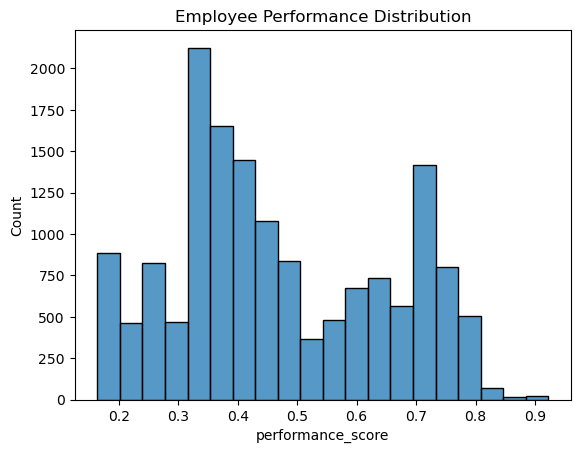

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(hr["performance_score"], bins=20)

plt.title("Employee Performance Distribution")

plt.show()

In [30]:
!pip install tensorflow keras opencv-python


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [34]:
import zipfile
with zipfile.ZipFile('archive (19).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [37]:
train_dir = "train"
test_dir = "test"

In [38]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    batch_size=32,
    class_mode="categorical"
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    batch_size=32,
    class_mode="categorical"
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [39]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation="relu",input_shape=(48,48,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation="relu"))

model.add(layers.Dense(train_data.num_classes,activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 23, 23, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 10, 10, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 4, 4, 128)       

In [40]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5


898/898 [==============================] - 873s 969ms/step - loss: 1.6851 - accuracy: 0.3236 - val_loss: 1.4884 - val_accuracy: 0.4349
Epoch 2/5
898/898 [==============================] - 90s 100ms/step - loss: 1.4219 - accuracy: 0.4541 - val_loss: 1.3153 - val_accuracy: 0.4971
Epoch 3/5
898/898 [==============================] - 92s 103ms/step - loss: 1.3182 - accuracy: 0.4995 - val_loss: 1.2500 - val_accuracy: 0.5254
Epoch 4/5
898/898 [==============================] - 90s 100ms/step - loss: 1.2594 - accuracy: 0.5197 - val_loss: 1.2127 - val_accuracy: 0.5411
Epoch 5/5
898/898 [==============================] - 93s 103ms/step - loss: 1.2169 - accuracy: 0.5391 - val_loss: 1.1846 - val_accuracy: 0.5506


In [41]:
loss, accuracy = model.evaluate(test_data)

print("Emotion Model Accuracy:", accuracy)

225/225 [==============================] - 9s 37ms/step - loss: 1.1846 - accuracy: 0.5506
Emotion Model Accuracy: 0.5505712032318115


In [44]:
model.save("emotion_model.keras")

In [47]:
import pickle

# save model
pickle.dump(model, open("sentiment_model.pkl","wb"))

# save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))

In [48]:
import numpy as np
import pandas as pd
import pickle
from tensorflow.keras.models import load_model

In [50]:
import os
os.listdir()

['.ipynb_checkpoints',
 'archive (19).zip',
 'emotion_model.h5',
 'emotion_model.keras',
 'imdb.csv',
 'sentiment_model.ipynb',
 'sentiment_model.pkl',
 'test',
 'train',
 'Uncleaned_employees_final_dataset.csv',
 'vectorizer.pkl']

In [52]:
import pickle

sentiment_model = pickle.load(open("sentiment_model.pkl","rb"))
vectorizer = pickle.load(open("vectorizer.pkl","rb"))

In [53]:
emotion_model = load_model("emotion_model.keras")

In [54]:
hr["performance_score"]

1        0.324141
2        0.176061
3        0.304646
4        0.414343
5        0.358485
           ...   
17412    0.785859
17413    0.184141
17414    0.184141
17415    0.184141
17416    0.774747
Name: performance_score, Length: 15424, dtype: float64

In [55]:
performance_score = hr["performance_score"].mean()

print("Performance Score:", performance_score)

Performance Score: 0.46949345634770945


In [58]:
type(sentiment_model)

keras.src.engine.sequential.Sequential

In [59]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# load dataset
df = pd.read_csv("imdb.csv")

# convert sentiment to numbers
df["sentiment"] = df["sentiment"].map({"positive":1,"negative":0})

# split data
X_train, X_test, y_train, y_test = train_test_split(
    df["review"], df["sentiment"], test_size=0.2, random_state=42
)

# vectorize text
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# train model
sentiment_model = LogisticRegression(max_iter=1000)
sentiment_model.fit(X_train_vec, y_train)

# check accuracy
pred = sentiment_model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, pred))

# save model
pickle.dump(sentiment_model, open("sentiment_model.pkl","wb"))
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))

Accuracy: 0.8959


In [60]:
import pickle

sentiment_model = pickle.load(open("sentiment_model.pkl","rb"))
vectorizer = pickle.load(open("vectorizer.pkl","rb"))

In [61]:
type(sentiment_model)

sklearn.linear_model._logistic.LogisticRegression

In [62]:
feedback = ["Management communication is very poor"]

feedback_vec = vectorizer.transform(feedback)

prediction = sentiment_model.predict(feedback_vec)

print("Prediction:", prediction)

Prediction: [0]


In [63]:
sentiment_score = float(prediction[0])
print("Sentiment Score:", sentiment_score)

Sentiment Score: 0.0


In [64]:
emotion_score = 0.7

In [65]:
culture_score = (
    0.35 * emotion_score +
    0.35 * sentiment_score +
    0.30 * performance_score
)

print("Final Culture Score:", culture_score)

Final Culture Score: 0.3858480369043128


In [66]:
def culture_label(score):
    
    if score >= 0.7:
        return "Excellent Work Culture"
    
    elif score >= 0.5:
        return "Moderate Work Culture"
    
    else:
        return "Poor Work Culture"

print("Culture Status:", culture_label(culture_score))

Culture Status: Poor Work Culture


In [67]:
import numpy as np
import pickle
from tensorflow.keras.models import load_model

# -------------------------------
# Load Sentiment Model
# -------------------------------

sentiment_model = pickle.load(open("sentiment_model.pkl","rb"))
vectorizer = pickle.load(open("vectorizer.pkl","rb"))

# -------------------------------
# Load Emotion Model
# -------------------------------

emotion_model = load_model("emotion_model.keras")

# -------------------------------
# HR Performance Score
# -------------------------------

performance_score = hr["performance_score"].mean()

print("Performance Score:", performance_score)

# -------------------------------
# Sentiment Prediction
# -------------------------------

feedback = ["Management communication is very poor"]

feedback_vec = vectorizer.transform(feedback)

sentiment_pred = sentiment_model.predict(feedback_vec)

sentiment_score = float(sentiment_pred[0])

print("Sentiment Score:", sentiment_score)

# -------------------------------
# Emotion Score (Example)
# -------------------------------

# In real system this comes from image prediction
emotion_score = 0.7

print("Emotion Score:", emotion_score)

# -------------------------------
# Final Culture Score
# -------------------------------

culture_score = (
    0.35 * emotion_score +
    0.35 * sentiment_score +
    0.30 * performance_score
)

print("\nFinal Culture Score:", culture_score)

# -------------------------------
# Culture Interpretation
# -------------------------------

if culture_score >= 0.7:
    culture_status = "Excellent Work Culture"

elif culture_score >= 0.5:
    culture_status = "Moderate Work Culture"

else:
    culture_status = "Poor Work Culture"

print("Culture Status:", culture_status)

Performance Score: 0.46949345634770945
Sentiment Score: 0.0
Emotion Score: 0.7

Final Culture Score: 0.3858480369043128
Culture Status: Poor Work Culture
